### **Mounting Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### **Inputing the Requirement**

In [ ]:
import datetime as dt, os

# filter config
TIMESTAMP     = dt.datetime.now().strftime('%d%m%Y')
COLUMNS = {
    'Date':      'Date',        # e.g. 'creation_time'
    'Media':     'Media',       # e.g. 'specific_resource_type'
    'Author':    'Author',      # e.g. 'from_username'
    'Mentions':  'Mentions',    # e.g. 'content'
    'Sentiment': 'Sentiment',   # e.g. 'final_sentiment'
    'Link':      'Link',
}
SENTIMENT_MAP   = {} # e.g. {'mixed': 'neutral'}
PATH            = '/content/drive/MyDrive/Data/Raw Data DPR 2026' # Path to access the data in google drive
FILE_NAME       = 'dpr26_agustus.xlsx'   # one file, or a pattern: '*.xlsx', 'dpr26_*.csv', '*'
ISSUES          = 'Whatever' # Changed based on your issues
OUT_DIR         = f'/content/drive/MyDrive/model_result/{ISSUES}_{TIMESTAMP}';os.makedirs(OUT_DIR,exist_ok=True) # To upload the result directly
TOT_PERIOD      = 'D'    # one month of data -> daily bins; use 'W' for multi-month exports
KEYWORDS        = []   # [] or None -> no filtering
REQUIRED        = []       # must-have terms (ALL of them); [] -> none
MIN_HITS        = 2                 # how many of KEYWORDS a row must match
EXACT_WORD      = False             
MAX_ENRICH      = None # None = enrich every topic; set e.g. 40 to cap API calls / runtime
TOP_N           = 5   # Issues that you want to show in the visualization, None = label every topic
EMBEDDING_MODEL = 'paraphrase-multilingual-mpnet-base-v2' # Used to turn words into vector
MODEL_REPO      ='faizonly5953/gemma2-9b-cpt-sahabatai-v1-instruct-GGUF' # Change the model based on the provider that you use
MODEL_FILE      = 'gemma2-9b-cpt-sahabatai-v1-instruct.q4_k_m.gguf' # Change the model based on the provider that you use

### **Notebook Set Up**

In [3]:
import torch

HAS_GPU = torch.cuda.is_available()
maj, mnr = (torch.version.cuda or "0.0").split(".")[:2]
assert not HAS_GPU or maj == "12", f"CUDA {torch.version.cuda}: no prebuilt llama-cpp/cuML wheel -- switch runtime"
CU_TAG = f"cu12{min(int(mnr), 4)}" if HAS_GPU else "cpu"   # abetlen publishes cu121..cu124 + cpu
print(f"Detected: {torch.cuda.get_device_name(0) if HAS_GPU else 'CPU-only'} -> {CU_TAG}")

%pip install -q "great[all] @ git+https://github.com/azmkto/GREAT-Tools.git"
%pip install -q bertopic datamapplot
!pip install -q llama-cpp-python --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/{CU_TAG}
if HAS_GPU:
    !pip install -q cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Detected: NVIDIA L4 -> cu124
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 25.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.6/350.6 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 155.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 78.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver doe

In [4]:
import pandas as pd, numpy as np, networkx as nx, matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import glob, re, json, textwrap, colorsys, math
import datamapplot, plotly.io as pio, plotly.express as px, plotly.graph_objects as go
from statsmodels.stats.multitest import multipletests

pio.renderers.default = 'vscode+colab' 

from great import plat_class, sent_class, MEDIA_MAP
from great.viz import prep
from great.viz.style import apply_style
from great.text import clean_for_bert, _load_topic_stopwords, WORDCLOUD_STOPWORDS_EXTRA

apply_style()

In [5]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import LlamaCPP
from llama_cpp import Llama
from huggingface_hub import hf_hub_download

In [6]:
USE_GPU_CLUSTERING = HAS_GPU   # HAS_GPU comes from cell 5
if HAS_GPU:
    try:
        from cuml.manifold import UMAP
        from cuml.cluster import HDBSCAN
    except Exception as e:   # cuml missing, driver mismatch, or the runtime needs a restart
        print(f"cuML unavailable ({type(e).__name__}) — falling back to CPU")
        USE_GPU_CLUSTERING = False

if not USE_GPU_CLUSTERING:
    from umap import UMAP
    from hdbscan import HDBSCAN
print("Clustering:", "cuML (GPU)" if USE_GPU_CLUSTERING else "umap-learn + hdbscan (CPU)")

Clustering: cuML (GPU)


### **Accessing The File**

In [7]:
def filter_by_keywords(df, col='Mentions', keywords=KEYWORDS, min_hits=MIN_HITS,
                       required=REQUIRED, exact_word=EXACT_WORD):
    """Keep rows matching >= min_hits of `keywords` AND all of `required`."""
    keywords, required = list(keywords or []), list(required or [])
    end = r'\b' if exact_word else ''
    has = {w: df[col].str.contains(rf'\b{re.escape(w)}{end}', case=False, na=False)
           for w in keywords + required}
    mask = pd.Series(True, index=df.index)
    if keywords:
        mask &= sum(has[w] for w in keywords) >= min(min_hits, len(keywords))
    for w in required:
        mask &= has[w]
    for w in keywords:
        print(f'   {w:<12} {int(has[w].sum()):>6} rows')
    print(f'{len(df)} -> {int(mask.sum())} rows kept')
    return df[mask]

In [8]:
SEPARATORS = ';,\t'
SENT_ALIASES = {'pos': 'positive', 'positif': 'positive', 'neg': 'negative',
                'negatif': 'negative', 'neu': 'neutral', 'netral': 'neutral'}


def _is_csv(f):
    return f.lower().endswith('.csv')


def _header_row(f):
    """First row (within the top 20) whose CELLS include every column named in COLUMNS."""
    want = set(COLUMNS.values())
    if _is_csv(f):
        with open(f, encoding='utf-8-sig', errors='replace') as fh:
            rows = [next(fh, '') for _ in range(20)]
        # Exact cell match: split on every candidate separator, so 'Date' never matches 'update_date'
        cells = [{c.strip().strip('"') for s in SEPARATORS for c in line.split(s)} for line in rows]
    else:
        top = pd.read_excel(f, header=None, nrows=20)
        cells = [set(row.astype(str).str.strip()) for _, row in top.iterrows()]
    hits = [i for i, c in enumerate(cells) if want <= c]
    assert hits, f'{f}: no header row with all of {sorted(want)} -- check COLUMNS in cell 3'
    return hits[0]


def _parse_dates(s):
    """DD/MM vs MM/DD decided from the data itself; timezone-aware stamps -> Jakarta local time."""
    if not pd.api.types.is_datetime64_any_dtype(s):
        txt = s.astype(str).str.strip()
        dm = txt.str.extract(r'^(\d{1,2})[/.-](\d{1,2})[/.-]\d{2,4}').astype(float)
        dayfirst = not (dm[1] > 12).any()           # a 2nd field above 12 can only be a day -> MM/DD
        s = pd.to_datetime(txt, format='mixed', dayfirst=dayfirst, errors='coerce')
    if s.dt.tz is not None:
        s = s.dt.tz_convert('Asia/Jakarta').dt.tz_localize(None)
    return s


def _read(f):
    h = _header_row(f)
    df = (pd.read_csv(f, skiprows=h, sep=None, engine='python', encoding_errors='replace')
          if _is_csv(f) else pd.read_excel(f, header=h))
    df.columns = df.columns.astype(str).str.strip()
    df = df.rename(columns={v: k for k, v in COLUMNS.items()})[list(COLUMNS)]
    df['Date'] = _parse_dates(df['Date'])

    bad = df['Date'].isna().sum()
    print(f"  {f.rsplit('/', 1)[-1]}: {df['Date'].min():%d %b %Y} – {df['Date'].max():%d %b %Y}"
          + (f'   ({bad} unparseable dates)' if bad else ''))
    return df


def _canon(col, vocab, aliases, setting):
    """Map each label to the vocab entry it names: exact (any case) first, then via an alias."""
    lookup = {v.lower(): v for v in vocab}
    aliases = {k.lower(): v.lower() for k, v in aliases.items()}

    def resolve(x):
        s = str(x).strip().lower()
        return lookup.get(s) or lookup.get(aliases.get(s, ''))

    mapping = {x: resolve(x) for x in col.dropna().unique()}
    bad = [x for x, v in mapping.items() if v is None]
    assert not bad, f'Unrecognised {col.name} labels {bad} -- add them to {setting} (valid: {sorted(vocab)})'
    return col.map(mapping)


files = sorted(glob.glob(f'{PATH}/{FILE_NAME}'))
assert files, f'No files match {PATH}/{FILE_NAME}'
print(f'Reading {len(files)} file(s):')

df = pd.concat([_read(f) for f in files], ignore_index=True)
df['Sentiment'] = _canon(df['Sentiment'], sent_class, {**SENT_ALIASES, **SENTIMENT_MAP}, 'SENTIMENT_MAP in cell 3')
df['Media'] = _canon(df['Media'], plat_class, MEDIA_MAP, 'MEDIA_MAP')

df = df.dropna(subset=['Mentions', 'Date']).drop_duplicates(subset='Mentions', keep='first')
df = filter_by_keywords(df)
len(df)

Reading 1 file(s):
  dpr26_agustus.xlsx: 01 Aug 2026 – 31 Aug 2026
43484 -> 43484 rows kept


43484

In [9]:
df1, start_date, end_date = prep.prepare_data(df)
print(f'{start_date} - {end_date}   |   {len(df1):,} rows')

01 Aug 2026 - 31 Aug 2026   |   43,484 rows


In [10]:
df1 = df1.assign(clean_text=df1['Mentions'].map(clean_for_bert))
n_tok = df1['clean_text'].fillna('').str.split().str.len()
print(f'Dropping {(n_tok < 3).sum():,} of {len(df1):,} rows with <3 tokens after cleaning')
df1 = df1[n_tok >= 3].reset_index(drop=True)      # filter the FRAME, then derive every list from it

# Turning the cleaned text data into a docs list
docs = df1['clean_text'].tolist()

# Turning the period timestamp into a docs list.
period = pd.to_datetime(df1['Date']).dt.to_period(TOT_PERIOD).dt.to_timestamp()
timestamps = period.tolist()
assert len(docs) == len(timestamps) == len(df1)

Dropping 246 of 43,484 rows with <3 tokens after cleaning


### **Topic Model Set Up**

In [11]:
model_path = hf_hub_download(
    repo_id=MODEL_REPO,
    filename=MODEL_FILE,
)
llm = Llama(model_path=model_path, n_gpu_layers=-1, n_ctx=8192, n_batch=512, verbose=False)

gemma2-9b-cpt-sahabatai-v1-instruct.q4_k(…): reconstructing file:   0%|          |  0.00B / 5.76GB            

gemma2-9b-cpt-sahabatai-v1-instruct.q4_k(…): downloading bytes:           |  0.00B            

llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


In [ ]:
prompt = """ Q:
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Give a short label of at most 8 words. Output ONLY the label.
Do not explain, do not apologise, do not mention missing context.
If the keywords are unclear, still give your best guess. Answer in Bahasa Indonesia
A:
"""

LLM_KW = dict(prompt=prompt, nr_docs=4, diversity=0.1, doc_length=100, tokenizer='whitespace')
llm_rep = LlamaCPP(llm, pipeline_kwargs={'stop': ['\n', 'Q:'], 'max_tokens': 32}, **LLM_KW)
representation_model = {'LLM': llm_rep}

In [13]:
N = len(docs)
MIN_CLUSTER = min(200, max(15, N // 100))
N_NEIGHBORS = min(100, max(15, N // 100))

sentence_model = SentenceTransformer(EMBEDDING_MODEL)
embeddings = sentence_model.encode(docs, batch_size=256, show_progress_bar=True)

umap_model = UMAP(n_neighbors=N_NEIGHBORS, n_components=5, min_dist=0.0,
                  metric='cosine', random_state=42, verbose=True)

hdbscan_model = HDBSCAN(min_cluster_size=MIN_CLUSTER, metric='euclidean',
                        cluster_selection_method='eom', prediction_data=True)

# Sastrawi + NLTK(id+en) + TOPIC_STOPWORDS_BASE -- the same set clean_for_topics() uses.
stopwords = _load_topic_stopwords() | WORDCLOUD_STOPWORDS_EXTRA

vectorizer_model = CountVectorizer(
    ngram_range=(1, 3),          # 3 -- 'rapat dengar pendapat', 'operasi tangkap tangan'
    stop_words=list(stopwords),
    # BERTopic fits this on ONE joined document per topic, so min_df counts topics, not
    # documents. Raising it deletes exactly the rare distinctive terms we want as labels.
    min_df=1,
    max_df=0.90,                 # drops terms present in >90% of TOPICS -- real filler
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]{2,}\b',
    lowercase=True,
    max_features=100_000,
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True,  # the real defence against 'prabowo' / 'pemerintah'
    bm25_weighting=True,
)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/169 [00:00<?, ?it/s]

In [14]:
topic_model = BERTopic(
    embedding_model=sentence_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    verbose=True,
)
topics, _ = topic_model.fit_transform(docs, embeddings)
topics = topic_model.reduce_outliers(docs, topics, strategy='c-tf-idf', threshold=0.1)
topics = topic_model.reduce_outliers(docs, topics, strategy='embeddings', embeddings=embeddings)
topic_model.update_topics(docs, topics=topics,
                          vectorizer_model=vectorizer_model,
                          ctfidf_model=ctfidf_model,
                          representation_model=representation_model)

2026-09-30 04:45:15,967 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


[2026-09-30 04:45:16.391] [CUML] [debug] Computing KNN Graph
[2026-09-30 04:45:16.890] [CUML] [debug] Computing fuzzy simplicial set


2026-09-30 04:45:18,659 - BERTopic - Dimensionality - Completed ✓
2026-09-30 04:45:18,661 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-30 04:45:19,583 - BERTopic - Cluster - Completed ✓
2026-09-30 04:45:19,595 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-30 04:45:52,724 - BERTopic - Representation - Completed ✓
2026-09-30 04:46:02,459 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
100%|██████████| 31/31 [00:22<00:00,  1.37it/s]


In [15]:
# Saving the fitted model + everything needed to redo plots without refitting
MODEL_DIR = f'{OUT_DIR}/model'

topic_model.vectorizer_model.vocabulary_ = {
    k: int(v) for k, v in topic_model.vectorizer_model.vocabulary_.items()}

topic_model.save(MODEL_DIR, serialization='safetensors', save_ctfidf=True,
                 save_embedding_model=EMBEDDING_MODEL)   # saves the model NAME; re-downloaded on load

# Per-document results: original row + its final topic (after outlier reduction).
df1.assign(Topic=np.asarray(topics)).to_parquet(f'{OUT_DIR}/documents_{ISSUES}.parquet', index=False)
np.save(f'{OUT_DIR}/embeddings_{ISSUES}.npy', embeddings.astype('float16'))  # fp16 halves the file
print('Saved to', OUT_DIR)

Saved to /content/drive/MyDrive/model_result/Whatever_30092026


#### **Refinement**

In [16]:
NOISE = "Outlier"

MAX_WORDS = 13
REFUSAL = re.compile(
    r"not possible|without additional|more information|would be necessary|"
    r"cannot|can't|unable|insufficient|unclear|no clear|as an ai|sorry|"
    r"tidak (dapat|bisa|mungkin|cukup)",
    re.I,
)

def label_for(tid, raw):
    """LLM label, cleaned; falls back to the top c-TF-IDF keywords if it refused or rambled."""
    label = re.sub(r'^(label|topic)\s*[:\-]\s*', '', raw.split('\n')[0], flags=re.I).strip(' "\'.,:;')
    if not label or REFUSAL.search(label) or len(label.split()) > MAX_WORDS:
        label = ' '.join(w for w, _ in topic_model.get_topic(tid)[:4]).title() or f'Topic {tid}'
    return label

info = topic_model.get_topic_info().sort_values('Count', ascending=False)
label_map, seen = {-1: NOISE}, {NOISE}
for tid, raw in zip(info['Topic'], info['LLM']):
    if tid == -1:
        continue
    name = label_for(tid, raw[0])
    if name in seen:     # same label twice would merge two clusters on the maps
        name = f'{name} #{tid}'
    seen.add(name)
    label_map[tid] = name

assert len(set(label_map.values())) == len(label_map), 'label_map not injective'
topic_model.set_topic_labels(label_map)

In [17]:
topics_arr = np.asarray(topics)
assert len(docs) == len(df1), f'{len(docs)} docs vs {len(df1)} rows -- zip would misalign'

clean_to_orig = dict(zip(docs, df1['Mentions']))
clean_to_link = dict(zip(docs, df1['Link']))


SENT_BASE = df1['Sentiment'].value_counts(normalize=True)   # corpus baseline, same role as in majas lift
LIFT_MIN = 0.25    # log2 units: a class must be ~19% over-represented to count as the topic's lean


def _sentiment_profile(tid):
    share = (df1.loc[topics_arr == tid, 'Sentiment']
             .value_counts(normalize=True).reindex(SENT_BASE.index, fill_value=0))
    with np.errstate(divide='ignore'):
        lift = np.log2(share / SENT_BASE)
    return share, lift


def _sentiment_lean(tid):
    """Most over-represented sentiment vs the corpus -- not the most frequent one."""
    share, lift = _sentiment_profile(tid)
    if share.sum() == 0 or lift.max() < LIFT_MIN:
        return 'Mixed'
    return lift.idxmax()


def _sentiment_text(tid, sep='\n'):
    share, lift = _sentiment_profile(tid)
    return sep.join(f'{c}: {share[c]:.0%} of topic vs {SENT_BASE[c]:.0%} of corpus (lift {lift[c]:+.2f})'
                    for c in SENT_BASE.index)

def _fmt(docs_list, max_words=120):
    return '\n'.join(f'{i}. ' + ' '.join(str(d).split()[:max_words])
                     for i, d in enumerate(docs_list, 1))

def _wrap(text, width=70):
    return '<br>'.join(textwrap.wrap(str(text), width=width))

# Shared by the 3-D map (cell 25) and the network (cell 29): black page + Montserrat font.
FONT_JS = """
document.body.style.margin = '0'; document.body.style.background = 'black';
var l = document.createElement('link');
l.rel = 'stylesheet';
l.href = 'https://fonts.googleapis.com/css2?family=Montserrat:wght@400;700&display=swap';
document.head.appendChild(l);
"""

In [19]:
FIELDS = ['summary', 'public_view', 'problem_statement']
SCHEMA = {'type': 'object', 'properties': {f: {'type': 'string'} for f in FIELDS}, 'required': FIELDS}

ENRICH = """You are a complexity physicist working in a socio-political and economic think tank,
responsible for monitoring public discourse and analyzing its trends.

Below is one topic from a BERTopic clustering of public discourse across news and social media.

Topic label: {label}

Keywords: {keywords}

Sentiment of this topic compared with the whole corpus
(lift = log2(topic share / corpus share); positive lift = over-represented):
{sentiment}

Example documents:
{documents}

Return JSON with exactly these fields:
1. summary           - 1-2 sentences explaining the issue to stakeholders and the public. Explain the issue; do not merely repeat the keywords.
2. public_view       - 1-2 sentences on how the public feels about this issue. Base it on the sentiment that is OVER-represented relative to the corpus (positive lift), not simply the largest share, and ground it in the example documents.
3. problem_statement - the main problem the public is discussing. Ground it in the over-represented sentiment; do not repeat the keywords.

Answer in Indonesian. Output only JSON.
"""


def enrich_topic(tid, rep_docs):
    """One LLM call -> {summary, public_view, problem_statement}; missing fields become ''."""
    content = ENRICH.format(
        label=label_map[tid],
        keywords=', '.join(w for w, _ in topic_model.get_topic(tid)[:10]),
        sentiment=_sentiment_text(tid),
        documents=_fmt([clean_to_orig.get(d, d) for d in rep_docs]),
    )
    r = llm.create_chat_completion(
        messages=[{'role': 'user', 'content': content}],
        response_format={'type': 'json_object', 'schema': SCHEMA},
        temperature=0.2, max_tokens=800,
    )
    out = json.loads(r['choices'][0]['message']['content'])
    return {f: (out.get(f) or '').strip() for f in FIELDS}


base = topic_model.get_topic_info().sort_values('Count',ascending=False)
enrich_ids = [t for t in base['Topic'] if t != -1][:MAX_ENRICH]
print(f'enriching {len(enrich_ids)} of {(base["Topic"] != -1).sum()} topics')

records = []
for tid in enrich_ids:
    rep_docs = topic_model.get_representative_docs(tid)[:4]
    try:
        d = enrich_topic(tid, rep_docs)
    except Exception as e:
        print(f'topic {tid} failed: {type(e).__name__}: {e}')
        d = dict.fromkeys(FIELDS, '')

    records.append({
        'Topic': tid,
        'Count': int(base.loc[base['Topic']==tid, 'Count'].iloc[0]),
        'Topic Name': label_map[tid],
        'Sentiment': _sentiment_lean(tid),
        'Sentiment Mix': _sentiment_text(tid, sep=' | '),
        'Issue Summary': d['summary'],
        'Public View': d['public_view'],
        'Public Post Example': next(filter(None, map(clean_to_link.get, rep_docs)), ''),  # first non-empty link
        'Problem Statement': d['problem_statement'],
    })

enriched = pd.DataFrame(records)
print(f"{(enriched['Issue Summary'] == '').sum()} of {len(enriched)} topics came back empty")
enriched.to_excel(f'{OUT_DIR}/final_result_topic_model_{ISSUES}.xlsx')

enriching 31 of 31 topics
0 of 31 topics came back empty


In [20]:
enriched.head(10)

,Topic,Count,Topic Name,Sentiment,Sentiment Mix,Issue Summary,Public View,Public Post Example,Problem Statement
0,0,9173,Pengamanan Aksi Demo di DPR,negative,positive: 38% of topic vs 57% of corpus (lift ...,Topik ini membahas tentang pengamanan aksi dem...,Publik cenderung memiliki pandangan negatif te...,https://www.cnnindonesia.com/nasional/20260827...,Masalah utama yang dibahas publik adalah kekha...
1,1,5037,Pengantar RUU APBN 2027 dan Nota Keuangan,positive,positive: 76% of topic vs 57% of corpus (lift ...,Presiden Prabowo Subianto menyampaikan pidato ...,Publik secara umum menyambut positif pidato Pr...,https://www.antaranews.com/berita/5694132/pida...,Publikasi mengenai pengantar RUU APBN 2027 dan...
2,6,2694,Pengelolaan Anggaran Daerah,positive,positive: 70% of topic vs 57% of corpus (lift ...,Topik ini membahas tentang pengelolaan anggara...,Publik secara umum memiliki pandangan positif ...,http://sorot.co/berita/dprd-dan-bupati-purwore...,Publikasi ini menunjukkan bahwa publik memilik...
3,2,2560,Pembahasan RUU Perampasan Aset,neutral,positive: 51% of topic vs 57% of corpus (lift ...,RUU Perampasan Aset sedang dibahas oleh Komisi...,Publik cenderung netral terhadap RUU Perampasa...,https://kabarpolitik.com/habiburokhman-komisi-...,Publikasi cenderung netral terhadap RUU Peramp...
4,8,1824,Peringatan HUT Kemerdekaan RI,positive,positive: 77% of topic vs 57% of corpus (lift ...,Topik ini membahas tentang peringatan Hari Ula...,Publik merasa positif dan antusias dalam mempe...,https://gokepri.com/merawat-tradisi-1-500-obor...,Masalah utama yang dibahas publik adalah penti...
5,12,1613,Pembukaan Sidang Tahunan MPR RI,neutral,positive: 56% of topic vs 57% of corpus (lift ...,Pembukaan Sidang Tahunan MPR RI membahas tenta...,Publik cenderung netral terhadap pembukaan sid...,https://www.suarainvestor.com/buka-sidang-dpr-...,Publik membahas tentang pentingnya penyusunan ...
6,4,1480,Destry Damayanti Gubernur Bank Indonesia,neutral,positive: 53% of topic vs 57% of corpus (lift ...,Destry Damayanti telah terpilih sebagai Gubern...,Publik secara umum menyambut positif terpilihn...,https://waspada.id/berita/ketua-dewan-komision...,Publikasi ini membahas tentang terpilihnya Des...
7,16,1394,Pelantikan dan Konsolidasi Partai Politik,Mixed,positive: 63% of topic vs 57% of corpus (lift ...,Topik ini membahas tentang pelantikan dan kons...,Publik cenderung memiliki pandangan positif te...,https://medanbisnisdaily.com/news/online/read/...,Publik tampaknya antusias dengan upaya partai ...
8,3,1367,Kebakaran Hutan dan Lahan di Kalimantan,neutral,positive: 56% of topic vs 57% of corpus (lift ...,Kebakaran hutan dan lahan (karhutla) di Kalima...,Publik merasa prihatin dengan meluasnya dampak...,https://waspada.id/artikel/wakil-ketua-komisi-...,Publik khawatir karhutla di Kalimantan akan be...
9,13,1221,"Pekanbaru, Riau, dan Sekitarnya",negative,positive: 50% of topic vs 57% of corpus (lift ...,"Topik ini membahas tentang Pekanbaru, Riau, da...",Publik cenderung memiliki pandangan negatif te...,https://www.kontrasriau.com/2026/08/reky-fitro...,Masalah utama yang dibahas publik adalah kiner...


### **Topic Map**

In [21]:
emb5 = topic_model.umap_model.embedding_
emb5 = emb5.get() if hasattr(emb5, 'get') else np.asarray(emb5)
xy_viz = UMAP(n_neighbors=15, n_components=2, min_dist=0.0,
              metric='euclidean', random_state=42).fit_transform(emb5)
# xyz_viz = UMAP(n_neighbors=15, n_components=3, min_dist=0.0,
#                metric='euclidean', random_state=42).fit_transform(emb5)

[2026-09-30 04:57:34.469] [CUML] [debug] Building knn graph using build_algo='brute_force_knn'


  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


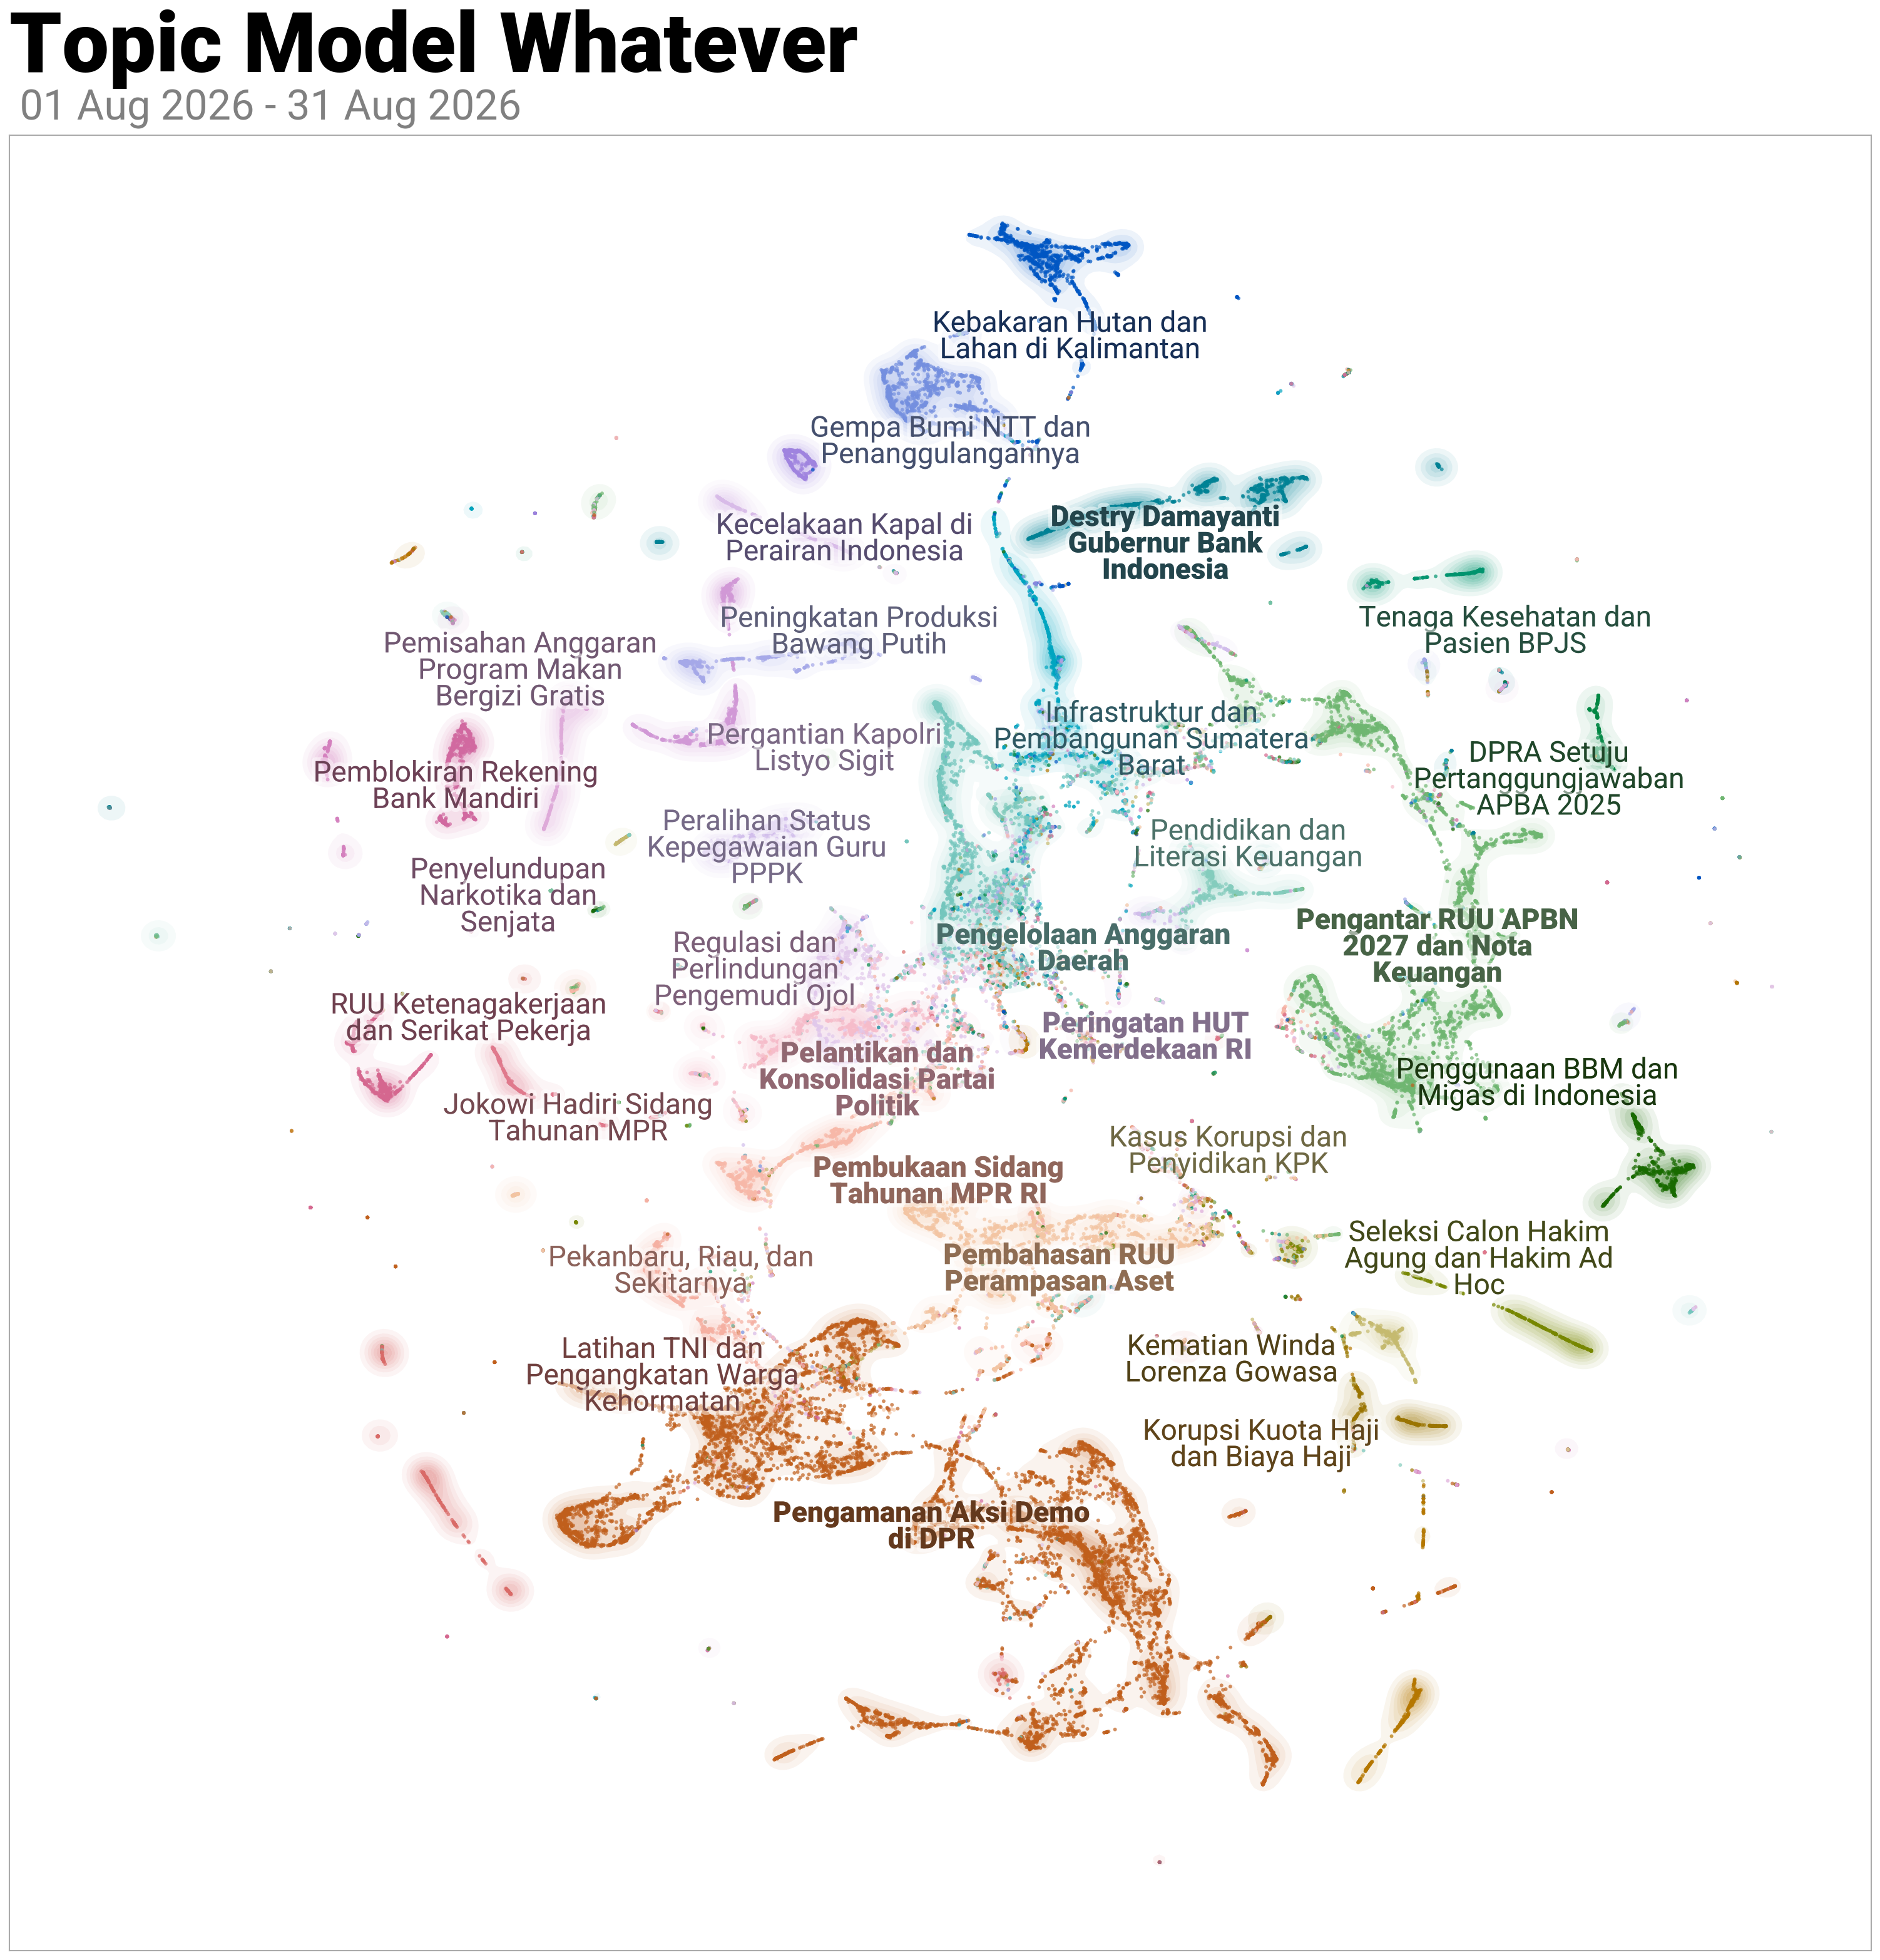

In [23]:
enriched_labels = np.array([label_map[t] for t in topics])
top_ids = base[base['Topic'] != -1].nlargest(8, 'Count')['Topic'].tolist()
highlight_labels = [label_map[t] for t in top_ids]

fig, ax = datamapplot.create_plot(
    xy_viz, enriched_labels,
    noise_label=NOISE,
    title=f'Topic Model {ISSUES}',
    sub_title=f' {start_date} - {end_date}',
    label_wrap_width=20,
    label_font_size=11,
    use_medoids=False,
    darkmode=False,
    dpi=300,
    figsize=(10, 10),
    add_glow=True,
    dynamic_label_size=True,
    label_over_points=True,
    point_size=2,
    alpha=0.7,
    highlight_labels=highlight_labels,
)

fig.savefig(f'{OUT_DIR}/topic_model_map_{ISSUES}.png');fig.savefig(f'{OUT_DIR}/topic_model_map_{ISSUES}.pdf')

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


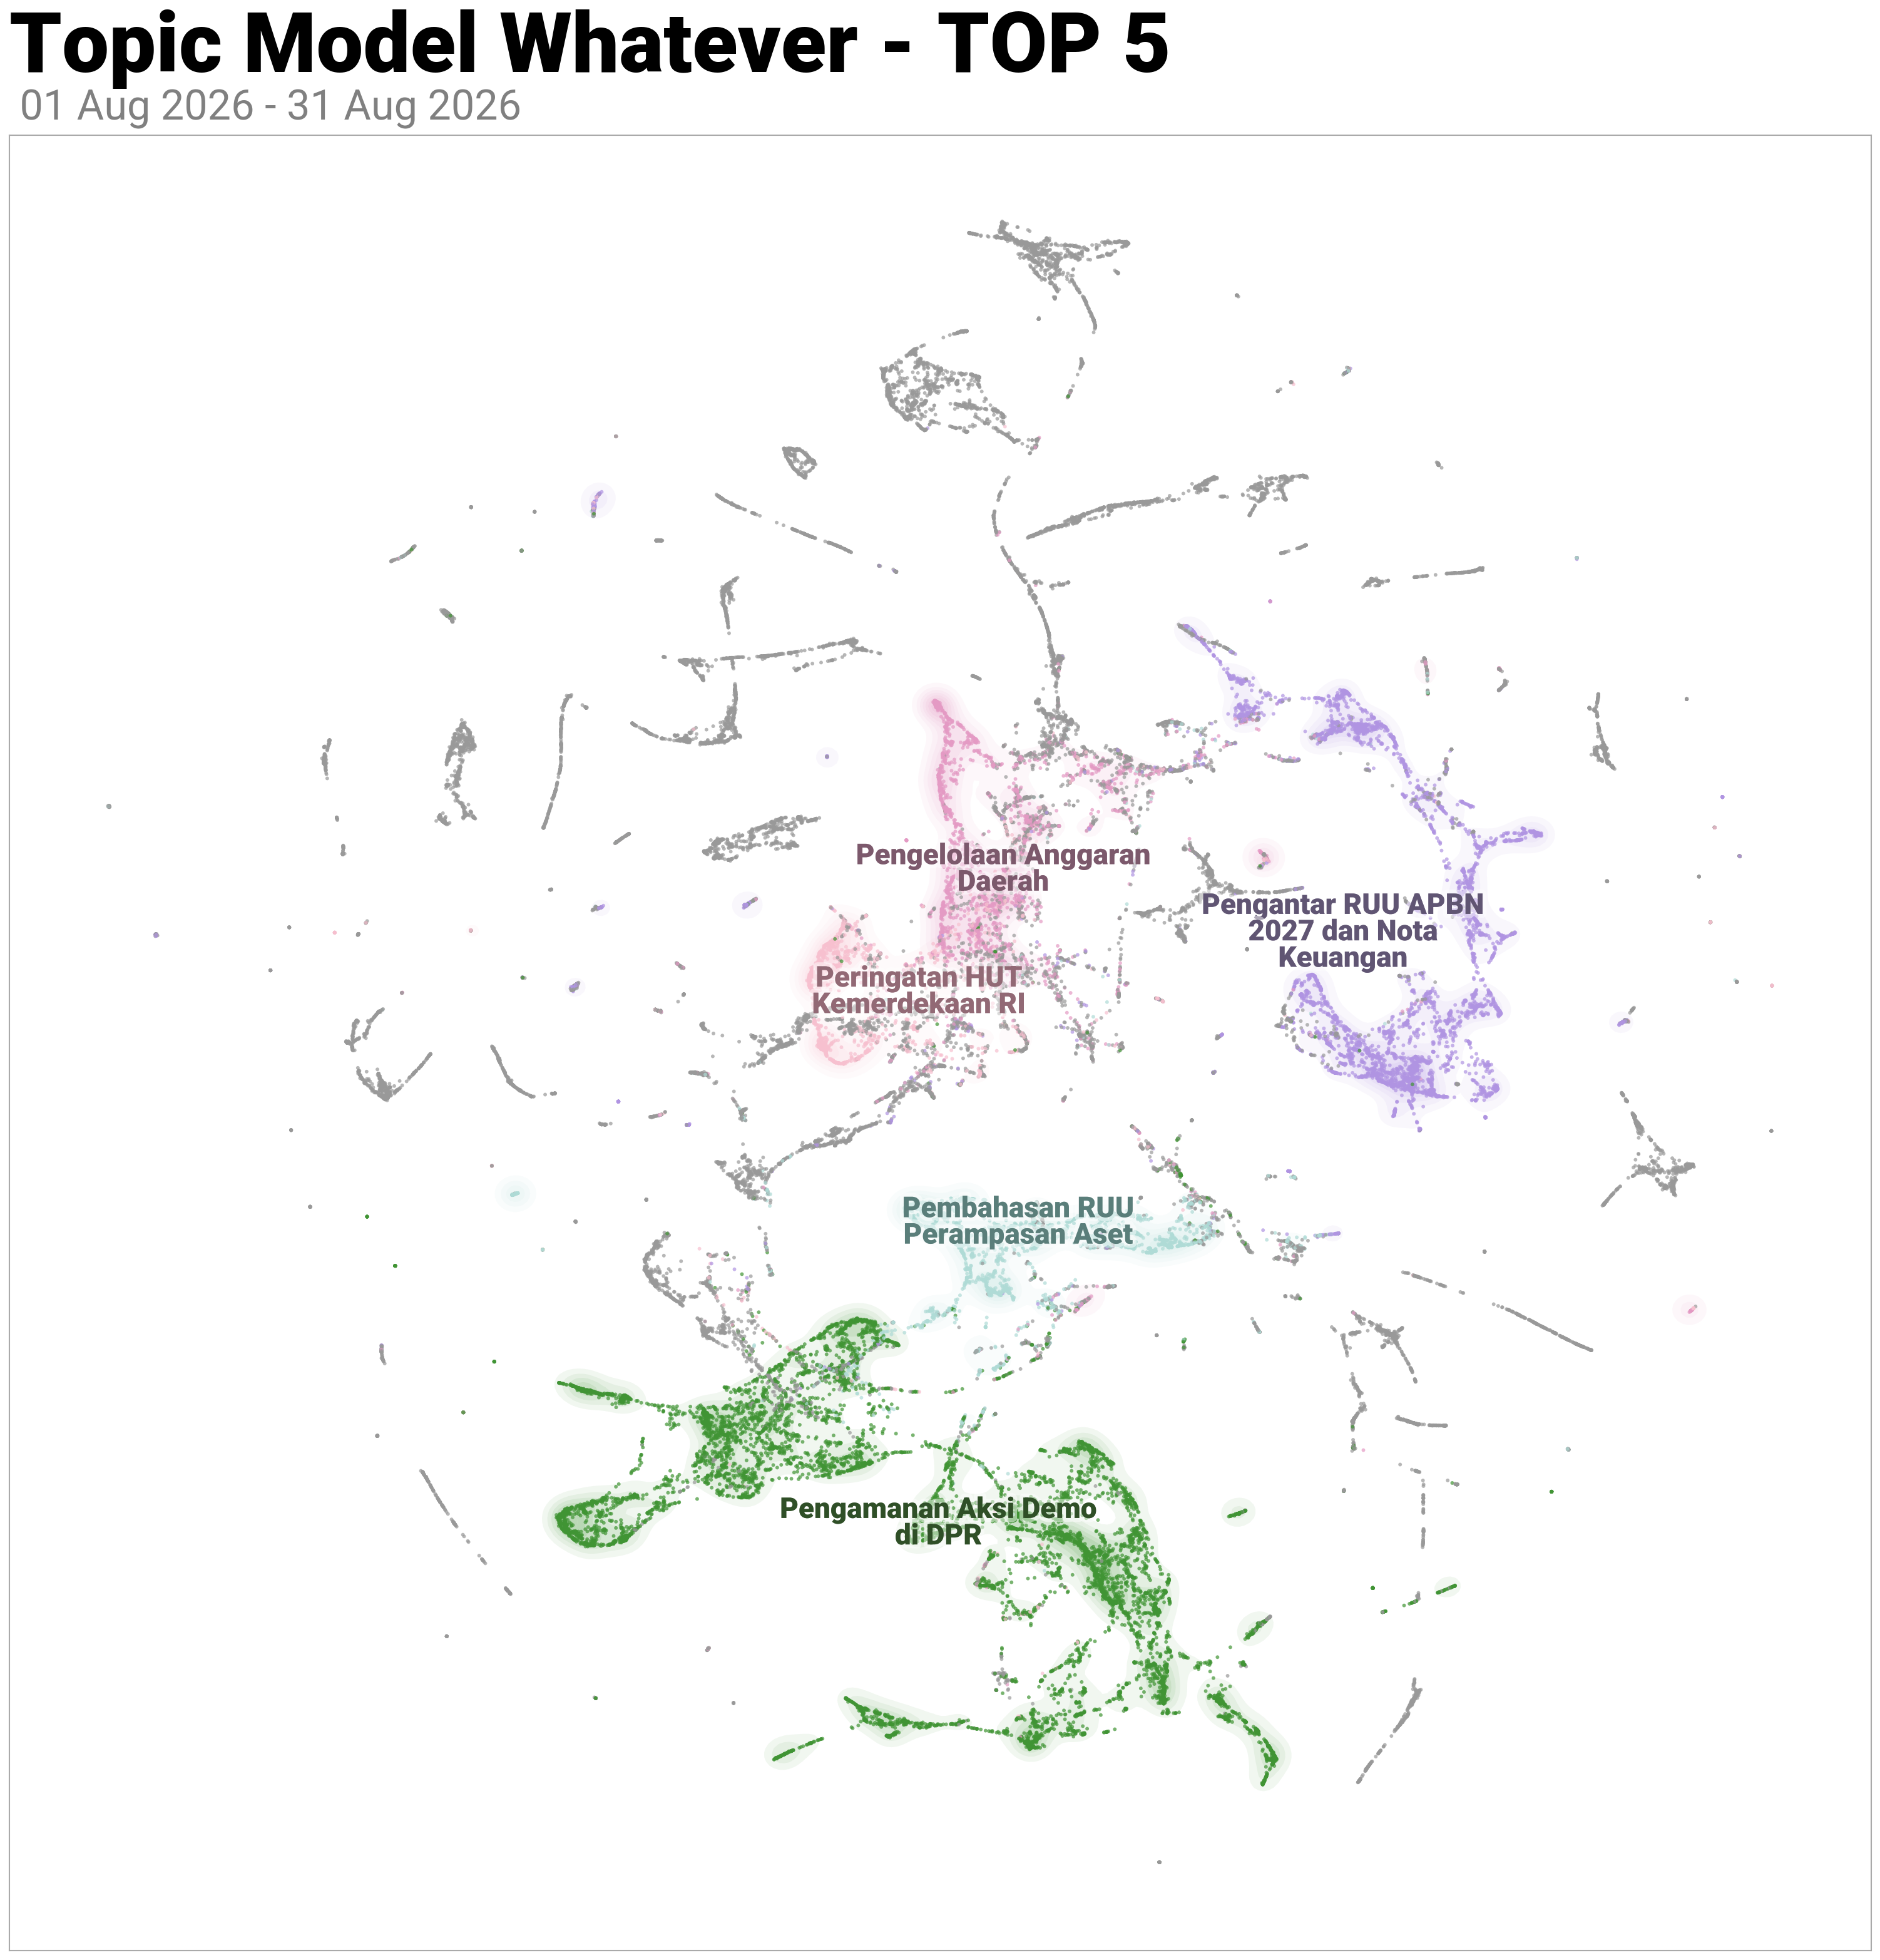

In [24]:
top_ids = base[base['Topic'] != -1].sort_values('Count', ascending=False)['Topic'].tolist()[:TOP_N]
highlight_labels = [label_map[t] for t in top_ids]
enriched_labels = np.where(np.isin(topics, top_ids),
                           [label_map[t] for t in topics], NOISE)

fig, ax = datamapplot.create_plot(
    xy_viz, enriched_labels,
    noise_label=NOISE,
    title=f'Topic Model {ISSUES} - TOP {TOP_N}',
    sub_title=f' {start_date} - {end_date}',
    label_wrap_width=20,
    label_font_size=11,
    use_medoids=False,
    darkmode=False,
    dpi=300,
    figsize=(10, 10),
    add_glow=True,
    dynamic_label_size=True,
    label_over_points=True,
    point_size=2,
    alpha=0.7,
    highlight_labels=highlight_labels,
)

fig.savefig(f'{OUT_DIR}/topic_model_map_{TOP_N}_{ISSUES}.png');fig.savefig(f'{OUT_DIR}/topic_model_map_{TOP_N}_{ISSUES}.pdf')

In [25]:
topics_over_time = topic_model.topics_over_time(docs, timestamps)
fig = topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=TOP_N, custom_labels=True)
fig.write_html(f'{OUT_DIR}/topic_over_time_{TOP_N}_{ISSUES}.html');fig.to_png(f'{OUT_DIR}/topic_over_time_{TOP_N}_{ISSUES}.png');fig.to_pdf(f'{OUT_DIR}/topic_over_time_{TOP_N}_{ISSUES}.pdf')
fig.show()

31it [00:43,  1.42s/it]


In [ ]:
# mask = topics_arr != -1   # drop the Outlier cluster

# cols = {'Sentiment': 'Sentiment', 'Issue Summary': 'Summary', 'Problem Statement': 'Problem'}
# info = enriched.set_index('Topic')[list(cols)].rename(columns=cols)
# info[['Summary', 'Problem']] = info[['Summary', 'Problem']].map(_wrap)   # wrap once per topic, not per point

# plot_df = pd.DataFrame({
#     'x': xyz_viz[mask, 0], 'y': xyz_viz[mask, 1], 'z': xyz_viz[mask, 2],
#     'Topic': enriched_labels[mask], 'tid': topics_arr[mask],
# }).join(info, on='tid').fillna('')

# fig = px.scatter_3d(
#     plot_df, x='x', y='y', z='z', color='Topic',
#     custom_data=['Topic', 'Sentiment', 'Summary', 'Problem'],
#     opacity=0.6,
# )
# fig.update_traces(hovertemplate=(
#     '<b>Topic</b><br>'
#     '%{customdata[0]} - %{customdata[1]}<br><br>'
#     '<b>Summary</b><br>'
#     '%{customdata[2]}<br><br>'
#     '<b>Problem Statement</b><br>'
#     '%{customdata[3]}'
#     '<extra></extra>'            # hides the trace-name box on the side
# ))

# fig.update_traces(marker=dict(size=0.7, line=dict(width=0)))

# for t in fig.data:
#     t.hoverlabel.bgcolor = t.marker.color     # each topic trace -> its own colour

# halo_traces = [
#     go.Scatter3d(x=t.x, y=t.y, z=t.z, mode='markers',
#                  marker=dict(size=1, color=t.marker.color, opacity=0.08),
#                  hoverinfo='skip', showlegend=False)
#     for t in fig.data
# ]
# fig = go.Figure(data=halo_traces + list(fig.data))

# fig.update_layout(
#     template='plotly_dark', showlegend=False, paper_bgcolor='black',
#     autosize=True, margin=dict(l=0, r=0, t=40, b=0),   # t=40 leaves room for the title
#     scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False), bgcolor='black'),
#     title=dict(text=f'Topic Model {ISSUES}', font=dict(family='Montserrat, sans-serif',color='white')),
#     hoverlabel=dict(
#         font=dict(family='Montserrat, sans-serif', size=16),
#         align='left',
#     ),
# )

# js = """
# var gd = document.getElementById('{plot_id}');
# var n = gd.data.length / 2, current = null;

# function focus(k) {
#   if (k === current) return;          // skip redundant restyles; 3-D redraws are expensive
#   current = k;
#   var op = [], idx = [];
#   for (var t = 0; t < 2 * n; t++) {
#     var halo = t < n, own = (t % n) === k;
#     idx.push(t);
#     op.push(k === null ? (halo ? 0.08 : 0.6)
#           : own        ? (halo ? 0.15 : 1.0)
#           :              (halo ? 0.0  : 0.03));
#   }
#   Plotly.restyle(gd, {'marker.opacity': op}, idx);
# }

# gd.on('plotly_hover',   function (ev) { focus(ev.points[0].curveNumber % n); });
# gd.on('plotly_unhover', function ()   { focus(null); });
# """

# fig.write_html(f'{OUT_DIR}/topic_map_interactive_{ISSUES}.html',
#                default_width='100vw', default_height='100vh', post_script=FONT_JS + js)

### **Topic Network** (Dropped)

#### Nodes and Edges Extraction

In [ ]:
# # One row per document: its topic and its day (outliers dropped).
# # Shared by the nodes here and the co-movement edges in the next cell.
# topic_days = pd.DataFrame({'Topic': topics_arr, 'Date': df1['Date'].dt.normalize()})
# topic_days = topic_days[topic_days['Topic'] != -1]

# # Nodes: one row per topic, with its active span (Gephi dynamic-timeline format)
# TEXT_COLS = ['Sentiment', 'Issue Summary', 'Problem Statement']
# nodes = (topic_days.groupby('Topic')['Date']
#          .agg(Size='size', Start='min', End='max')
#          .assign(End=lambda s: s['End'] + pd.Timedelta(days=1),      # half-open interval
#                  Label=lambda s: s.index.map(label_map))
#          .join(enriched.set_index('Topic')[TEXT_COLS])
#          .fillna({c: '' for c in TEXT_COLS})                          # topics skipped by MAX_ENRICH
#          .rename_axis('Id').reset_index())

# to_ms = lambda s: (s.astype('int64') // 10**6).astype(str)           # epoch milliseconds for Gephi
# nodes['Interval'] = '<[' + to_ms(nodes['Start']) + ', ' + to_ms(nodes['End']) + ']>'
# nodes.to_csv(f'{OUT_DIR}/topic_nodes_{ISSUES}.csv', index=False)

In [ ]:
# # ---- Edges: topics whose daily volume co-moves beyond the news cycle ----
# ALPHA = 0.05   # false-discovery rate for the Benjamini-Hochberg correction
# BLOCK = 3      # days per shuffle block; keeps short-range autocorrelation in the null (1 = plain shuffle)

# # 1. Daily volume matrix C: days x topics, with zero-mention days filled in
# counts = topic_days.groupby(['Date', 'Topic']).size().unstack(fill_value=0).asfreq('D', fill_value=0)
# C = counts.to_numpy(float)
# T, K = C.shape
# iu = np.triu_indices(K, 1)                      # every topic pair once
# m, n_blocks = len(iu[0]), math.ceil(T / BLOCK)
# assert K >= 2, 'Need at least two topics to build a co-movement network'

# if T < 14:
#     print(f'Warning: only {T} days of data -- correlations over so few points are unreliable')
# if math.factorial(n_blocks) < m / ALPHA:
#     print(f'Warning: {n_blocks} blocks allow too few distinct shuffles for BH to reject any of {m} pairs '
#           f'-- expect zero edges. Lower BLOCK or use a longer export.')

# # 2. Residual of each topic after removing the news cycle (all OTHER topics' volume) and a linear trend
# Y = np.log1p(C)
# total = C.sum(axis=1)
# trend = np.arange(T) - (T - 1) / 2
# R = np.empty_like(Y)
# for k in range(K):
#     X = np.column_stack([np.ones(T), np.log1p(total - C[:, k]), trend])
#     beta, *_ = np.linalg.lstsq(X, Y[:, k], rcond=None)
#     R[:, k] = Y[:, k] - X @ beta
# obs = np.corrcoef(R.T)[iu]

# # 3. Null model: block-shuffle each topic's residuals INDEPENDENTLY, so cross-topic co-movement is destroyed
# B = max(10_000, math.ceil(m / ALPHA))           # BH needs p down to ALPHA/m; smallest reachable p is 1/(B+1)
# rng = np.random.default_rng(42)
# blocks = np.array_split(np.arange(T), n_blocks)


# def _block_shuffle():
#     """Day order with the blocks permuted -- called once per topic, per replicate."""
#     return np.concatenate([blocks[j] for j in rng.permutation(n_blocks)])


# exceed = np.zeros(m)                            # running count, not a B x m matrix of null correlations
# for _ in range(B):
#     Rp = np.column_stack([R[_block_shuffle(), k] for k in range(K)])
#     exceed += np.abs(np.corrcoef(Rp.T)[iu]) >= np.abs(obs)

# # 4. Two-sided permutation p-values -> BH -> positive pairs become edges
# p = (1 + exceed) / (B + 1)
# reject, q, *_ = multipletests(p, alpha=ALPHA, method='fdr_bh')

# tids = counts.columns.to_numpy()
# pairs = pd.DataFrame({'Source': tids[iu[0]], 'Target': tids[iu[1]], 'r': obs, 'p': p, 'q': q})
# edges = pairs[reject & (pairs['r'] > 0)].rename(columns={'r': 'Weight'}).reset_index(drop=True)
# anti = pairs[reject & (pairs['r'] < 0)]         # topics that crowd each other out
# print(f'{len(edges)} positive / {len(anti)} negative significant pairs out of {m} (B={B:,})')
# edges.to_csv(f'{OUT_DIR}/topic_edges_{ISSUES}.csv', index=False)

0 positive / 0 negative significant pairs out of 465 (B=10,000)


#### **Topic Network Visualization**

In [ ]:
# # Defining main visualization feature
# G = nx.Graph()
# G.add_nodes_from(nodes['Id'])
# G.add_weighted_edges_from(edges[['Source', 'Target', 'Weight']].itertuples(index=False))

# ids = list(G.nodes())
# nodes_by_id = nodes.set_index('Id').loc[ids]      # row order == ids, so every column lines up with the nodes
# pos = nx.spring_layout(G, weight='weight', seed=42)
# degrees = dict(G.degree())

# # Golden-angle pastels: RGB for matplotlib, hex for Plotly -- same colour per topic in both plots
# node_rgb = {n: colorsys.hls_to_rgb(k * 137.508 % 360 / 360, 0.78, 0.65) for k, n in enumerate(ids)}
# node_colors = [to_hex(node_rgb[i]) for i in ids]

No topic pairs co-moved beyond the news cycle (block-permutation test, BH q < 0.05)


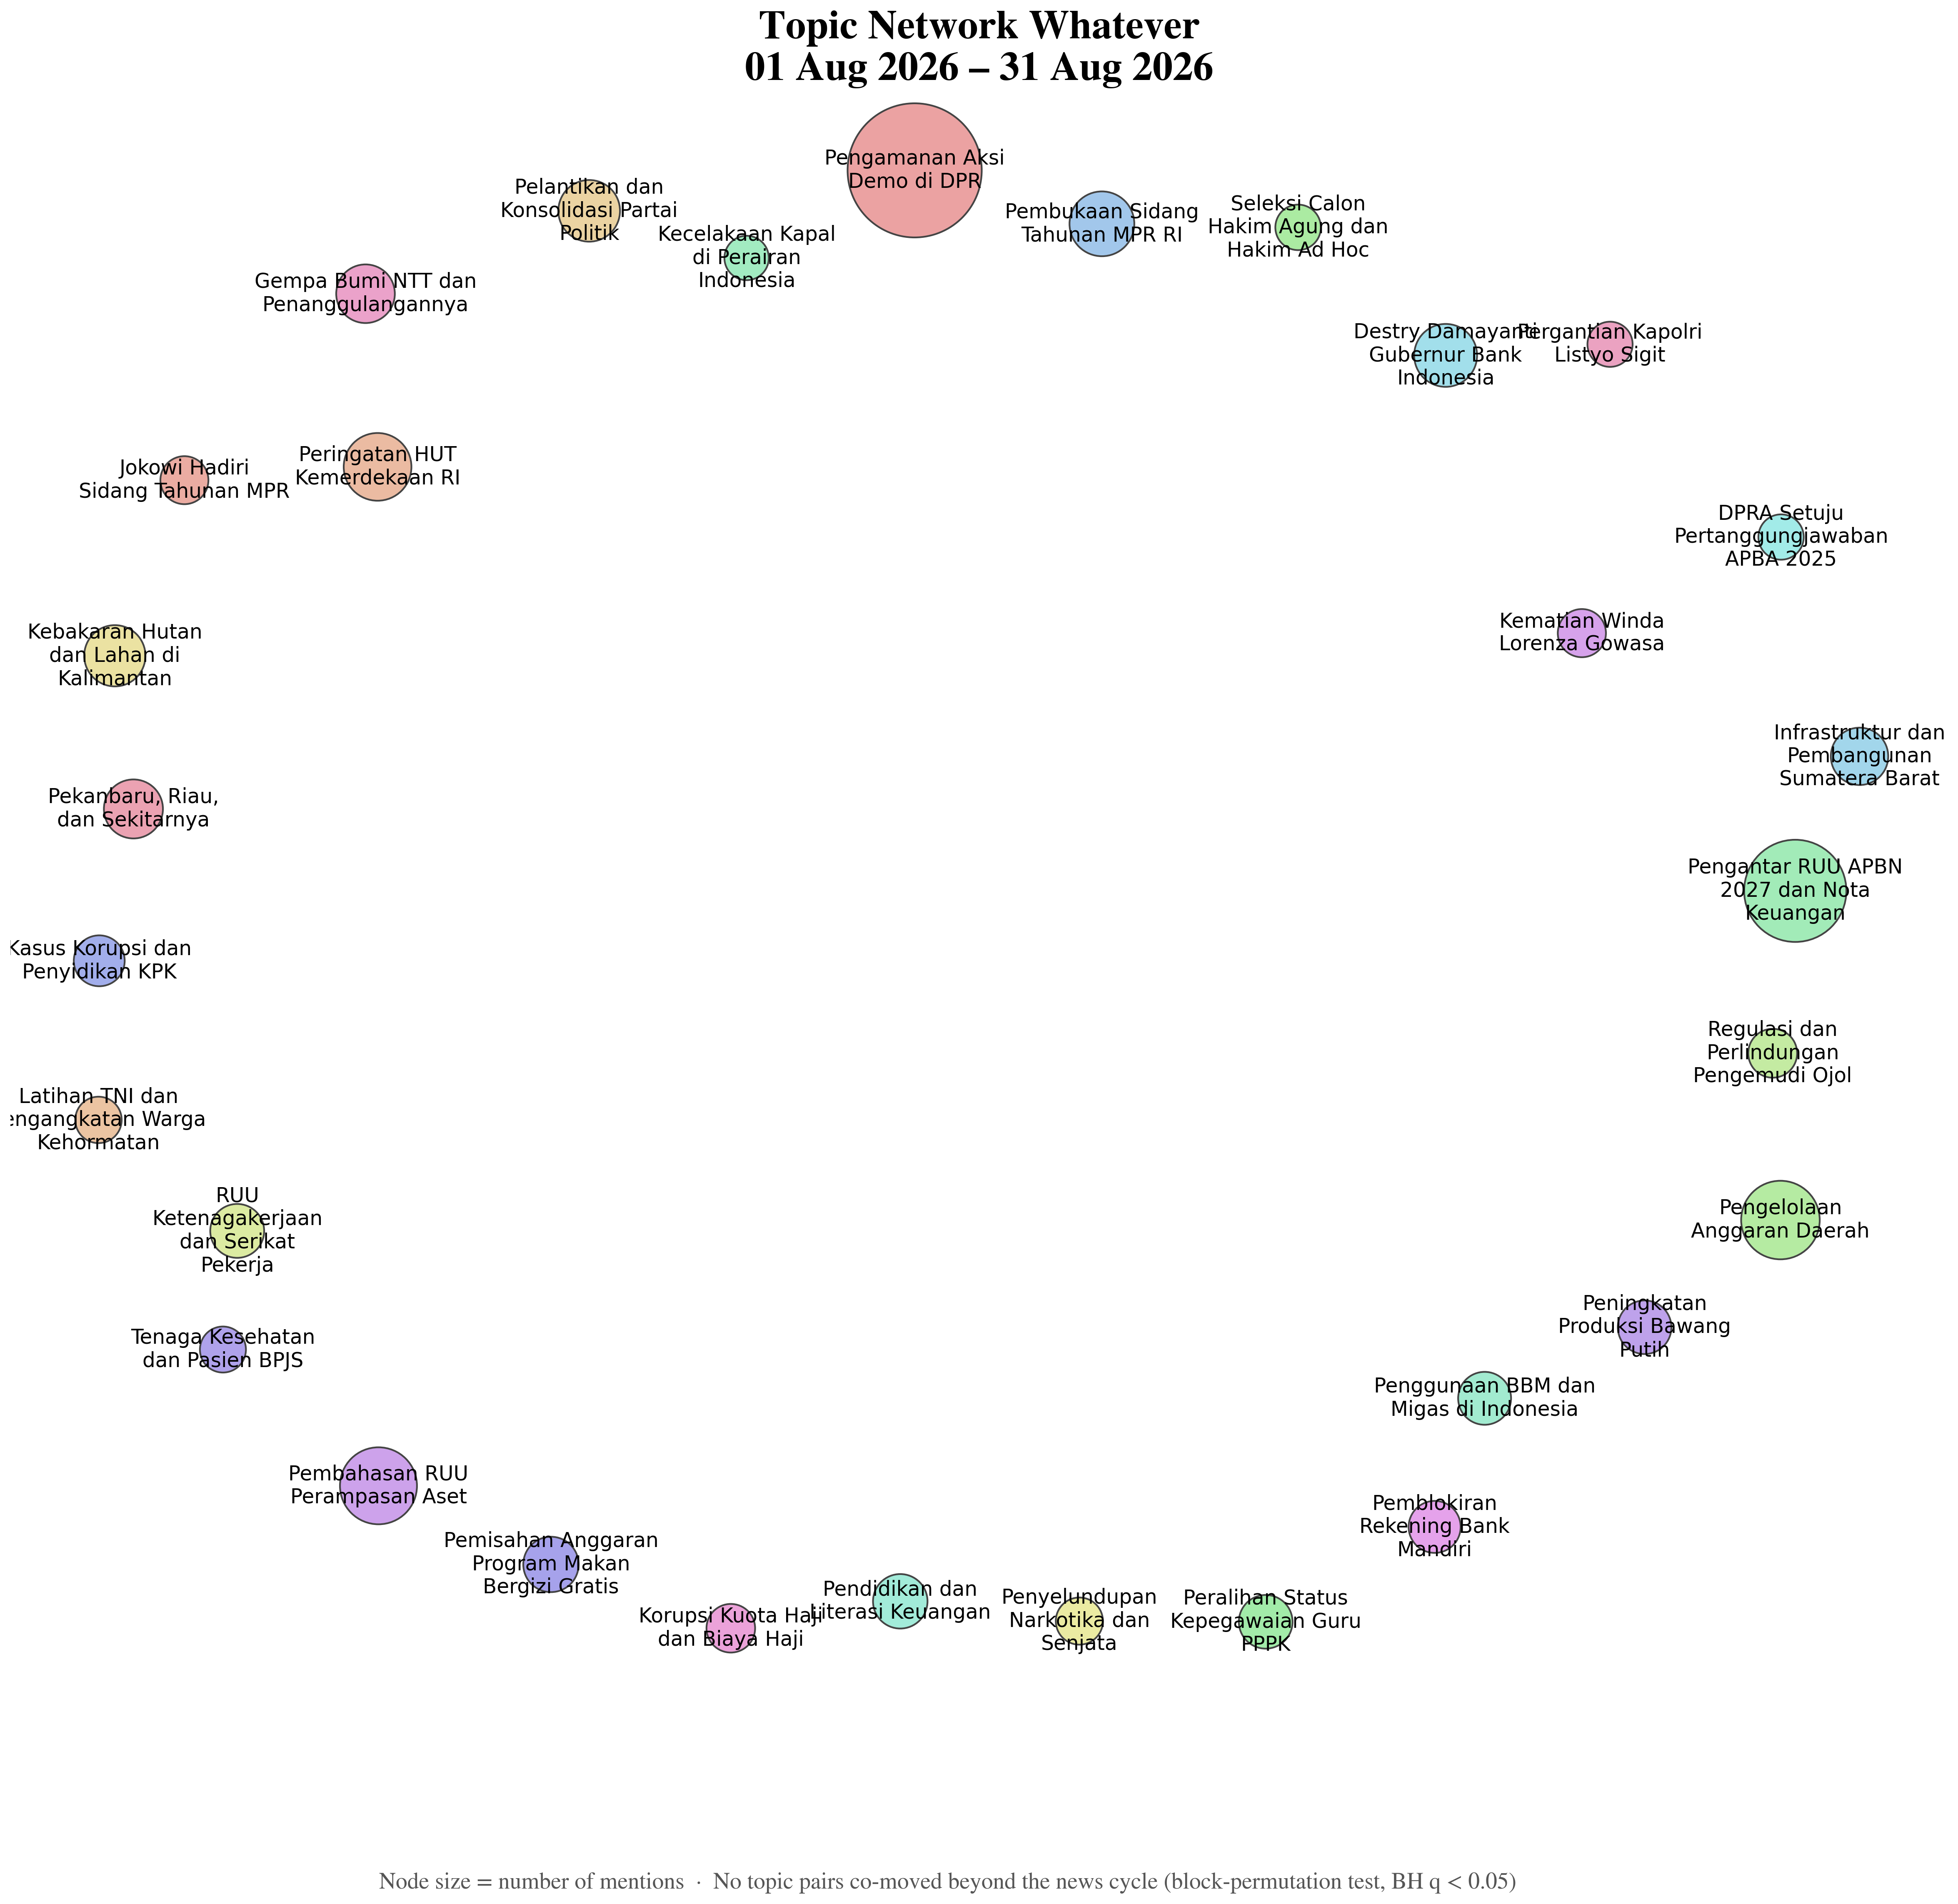

In [ ]:
# # Static network visualization for report needs
# fig_static, ax = plt.subplots(figsize=(12, 10))
# test = f'block-permutation test, BH q < {ALPHA}'

# w = np.array([d['weight'] for _, _, d in G.edges(data=True)])
# if w.size:                                  # the significance test can legitimately keep zero edges
#     nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#9a9a9a', alpha=0.6,
#                            width=0.5 + 3 * (w - w.min()) / (np.ptp(w) or 1))
#     edge_note = f'Edge = daily volumes co-move beyond the news cycle ({test})  ·  Edge width = residual correlation'
# else:
#     edge_note = f'No topic pairs co-moved beyond the news cycle ({test})'
#     print(edge_note)

# size = nodes_by_id['Size'].to_numpy()
# nx.draw_networkx_nodes(G, pos, nodelist=ids, ax=ax,
#                        node_size=150 + 2000 * size / size.max(),    # area ∝ number of mentions
#                        node_color=[node_rgb[i] for i in ids],
#                        edgecolors='#444444', linewidths=0.6)
# nx.draw_networkx_labels(G, pos, {i: textwrap.fill(l, 18) for i, l in nodes_by_id['Label'].items()},
#                         ax=ax, font_size=7)

# ax.set_title(f'Topic Network {ISSUES}\n{start_date} – {end_date}', fontsize=14, fontweight='bold')
# ax.axis('off')
# fig_static.text(0.5, 0.02, f'Node size = number of mentions  ·  {edge_note}',
#                 ha='center', fontsize=8, color='#555555')

# for ext in ('png', 'pdf'):                  # pdf = vector, for print
#     fig_static.savefig(f'{OUT_DIR}/topic_network_static_{ISSUES}.{ext}', bbox_inches='tight', facecolor='white')
# plt.show()


In [ ]:
# # Traces and layout for interactive network
# ex, ey = [], []
# for s, t in edges[['Source', 'Target']].itertuples(index=False):
#     ex += [pos[s][0], pos[t][0], None]
#     ey += [pos[s][1], pos[t][1], None]
# edge_trace = go.Scatter(x=ex, y=ey, mode='lines', line=dict(width=1, color='#666666'),
#                         opacity=0.4, hoverinfo='skip', showlegend=False)

# # Empty until hover fills it with the hovered node's edges; drawn under the nodes.
# highlight_trace = go.Scatter(x=[], y=[], mode='lines', line=dict(width=2, color='white'),
#                              hoverinfo='skip', showlegend=False)

# hover = [f"<b>Topic</b><br>{r['Label']} - {r['Sentiment']}<br><br>"
#          f"<b>Summary</b><br>{_wrap(r['Issue Summary'])}<br><br>"
#          f"<b>Problem Statement</b><br>{_wrap(r['Problem Statement'])}"
#          for _, r in nodes_by_id.iterrows()]

# node_trace = go.Scatter(
#     x=[pos[i][0] for i in ids], y=[pos[i][1] for i in ids], mode='markers',
#     marker=dict(size=[6 + degrees[i] ** 0.5 * 6 for i in ids],   # sqrt scale -- linear made hubs dominate
#                 color=node_colors, line=dict(width=0)),
#     hovertext=hover, hoverinfo='text', hoverlabel=dict(bgcolor=node_colors), showlegend=False,
# )

# # Trace order is load-bearing for the JS in the next cell: edges, highlight, nodes LAST.
# fig_net = go.Figure(data=[edge_trace, highlight_trace, node_trace])
# fig_net.update_layout(
#     template='plotly_dark', showlegend=False, paper_bgcolor='black', plot_bgcolor='black',
#     autosize=True, margin=dict(l=0, r=0, t=40, b=0),
#     xaxis=dict(visible=False), yaxis=dict(visible=False),
#     font=dict(family='Montserrat, sans-serif'),
#     hoverlabel=dict(font=dict(family='Montserrat, sans-serif', size=16), align='left'),
#     title=dict(text=f'Topic Network {ISSUES}', font=dict(color='white')),
# )

In [ ]:
# # Hover text adjustment and saving
# # The browser knows point numbers, not topic ids, so neighbour lists are indexed by position in `ids`.
# index_of = {n: k for k, n in enumerate(ids)}
# neighbours = [[index_of[v] for v in G.neighbors(u)] for u in ids]

# NETWORK_JS = """
# var gd = document.getElementById('{plot_id}');
# var NB = __NB__;
# var nodeIdx = gd.data.length - 1, hiIdx = nodeIdx - 1;
# var edgeIdx = Array.from({length: hiIdx}, (_, k) => k);

# gd.on('plotly_hover', function (ev) {
#   var p = ev.points[0];
#   if (p.curveNumber !== nodeIdx) return;
#   var i = p.pointNumber, keep = new Set(NB[i].concat([i]));
#   var xs = gd.data[nodeIdx].x, ys = gd.data[nodeIdx].y, ex = [], ey = [];
#   NB[i].forEach(function (j) { ex.push(xs[i], xs[j], null); ey.push(ys[i], ys[j], null); });
#   Plotly.restyle(gd, {'marker.opacity': [xs.map((_, k) => keep.has(k) ? 1 : 0.1)]}, [nodeIdx]);
#   Plotly.restyle(gd, {opacity: 0.05}, edgeIdx);
#   Plotly.restyle(gd, {x: [ex], y: [ey], 'line.color': gd.data[nodeIdx].marker.color[i]}, [hiIdx]);
# });

# gd.on('plotly_unhover', function () {
#   Plotly.restyle(gd, {'marker.opacity': 1}, [nodeIdx]);
#   Plotly.restyle(gd, {opacity: 0.4}, edgeIdx);
#   Plotly.restyle(gd, {x: [[]], y: [[]]}, [hiIdx]);
# });
# """

# fig_net.write_html(f'{OUT_DIR}/topic_network_interactive_{ISSUES}.html',
#                    default_width='100vw', default_height='100vh',
#                    post_script=FONT_JS + NETWORK_JS.replace('__NB__', json.dumps(neighbours)))


#### Network Statistics

In [ ]:
# # Whole-graph statistics
# n, m = G.number_of_nodes(), G.number_of_edges()
# components = list(nx.connected_components(G))
# G_lcc = G.subgraph(max(components, key=len))

# stats = {
#     'Nodes': n,
#     'Edges': m,
#     'Density': nx.density(G),
#     'Average degree': 2 * m / n,
#     'Average clustering': nx.average_clustering(G),
#     'Transitivity (global clustering)': nx.transitivity(G),
#     'Connected components': len(components),
#     'Largest component (nodes)': G_lcc.number_of_nodes(),
#     'Diameter, largest component (hops)': nx.diameter(G_lcc),
#     'Avg shortest path, largest component (hops)': nx.average_shortest_path_length(G_lcc),
# }

# # Both divide by the edge count, so they are undefined for a network with no edges.
# if m:
#     communities = nx.community.greedy_modularity_communities(G, weight='weight')
#     stats['Degree assortativity'] = nx.degree_assortativity_coefficient(G)
#     stats[f'Modularity ({len(communities)} greedy communities)'] = nx.community.modularity(
#         G, communities, weight='weight')
# else:
#     print('No edges: degree assortativity and modularity are undefined for this period.')

# for k, v in stats.items():
#     print(f'{k:<46} {v:.4g}')
# pd.Series(stats, name='Value').to_csv(f'{OUT_DIR}/topic_network_stats_{ISSUES}.csv', index_label='Metric')


No edges: degree assortativity and modularity are undefined for this period.
Nodes                                          31
Edges                                          0
Density                                        0
Average degree                                 0
Average clustering                             0
Transitivity (global clustering)               0
Connected components                           31
Largest component (nodes)                      1
Diameter, largest component (hops)             0
Avg shortest path, largest component (hops)    0


In [ ]:
# per-topic centrality
# Strong co-movement = short distance: path-based measures read 'dist' as a length.
for _, _, d in G.edges(data=True):
    d['dist'] = 1 / d['weight']

try:
    eigen = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality didn't converge (graph likely degenerate) -- left blank")
    eigen = {}

centrality = (nodes_by_id[['Label', 'Sentiment']]
              .assign(Degree=pd.Series(degrees),
                      Betweenness=pd.Series(nx.betweenness_centrality(G, weight='dist')),
                      Closeness=pd.Series(nx.closeness_centrality(G, distance='dist')),
                      Eigenvector=pd.Series(eigen, dtype=float))
              .rename_axis('Topic')
              .sort_values('Eigenvector', ascending=False))

print(centrality.to_string())
centrality.to_csv(f'{OUT_DIR}/topic_centrality_{ISSUES}.csv')

                                                 Label Sentiment  Degree  Betweenness  Closeness  Eigenvector
Topic                                                                                                        
0                          Pengamanan Aksi Demo di DPR  negative       0          0.0        0.0     0.179605
1            Pengantar RUU APBN 2027 dan Nota Keuangan  positive       0          0.0        0.0     0.179605
2                       Pembahasan RUU Perampasan Aset   neutral       0          0.0        0.0     0.179605
3              Kebakaran Hutan dan Lahan di Kalimantan   neutral       0          0.0        0.0     0.179605
4             Destry Damayanti Gubernur Bank Indonesia   neutral       0          0.0        0.0     0.179605
5                 Gempa Bumi NTT dan Penanggulangannya   neutral       0          0.0        0.0     0.179605
6                          Pengelolaan Anggaran Daerah  positive       0          0.0        0.0     0.179605
7      Pem